In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import os
from scipy import stats
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import OLSInfluence

# Modeling

In [29]:
new_products = pd.read_csv("../data/new_products.csv")
new_products.shape

(5056, 29)

In [30]:
#Nested Linear Models
cat = "C(primary_category, Treatment('Skincare'))"

m1 = smf.ols(
    f"log_price ~ {cat}",
    data=new_products
).fit(cov_type="HC2")

m2 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock""",
    data=new_products
).fit(cov_type="HC2")

m3 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count""",
    data=new_products
).fit(cov_type="HC2")

m4 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count
        + has_retinol + has_niacinamide + has_hyaluronic
        + has_vitamin_c + has_aha_bha + has_peptides
        + has_spf + has_fragrance + has_ceramides + has_vitamin_e""",
    data=new_products
).fit(cov_type="HC2")

new_products["is_fragrance_or_hair"] = new_products["primary_category"].isin(["Fragrance", "Hair"]).astype(int)

m5 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count
        + has_retinol + has_niacinamide + has_hyaluronic
        + has_vitamin_c + has_aha_bha + has_peptides
        + has_spf + has_fragrance + has_ceramides + has_vitamin_e
        + has_fragrance:is_fragrance_or_hair""",
    data=new_products
).fit(cov_type="HC2")

m6 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count
        + has_retinol + has_niacinamide + has_hyaluronic
        + has_vitamin_c + has_aha_bha + has_peptides
        + has_spf + has_fragrance + has_ceramides + has_vitamin_e
        + has_fragrance:is_fragrance_or_hair
        + size_ml:{cat}""",
    data=new_products
).fit(cov_type="HC2")

In [31]:
pd.set_option('display.max_rows', None)  # show all rows
results = pd.DataFrame({
    'coef': m5.params,
    'std_err': m5.bse,
    'p-value': m5.pvalues,
    'CI_lower': m5.conf_int()[0],
    'CI_upper': m5.conf_int()[1]
}).round(4)
print(m5.summary())
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

results = pd.DataFrame({
    'coef': m5.params,
    'std_err': m5.bse,
    'z': m5.tvalues,
    'p-value': m5.pvalues,
    'CI_lower': m5.conf_int()[0],
    'CI_upper': m5.conf_int()[1]
}).round(4)

print(results.to_string())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     84.03
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        21:31:30   Log-Likelihood:                -4521.1
No. Observations:                5056   AIC:                             9090.
Df Residuals:                    5032   BIC:                             9247.
Df Model:                          23                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [32]:

comparisons = [
    ("m1 vs m2", m1, m2),
    ("m2 vs m3", m2, m3),
    ("m3 vs m4", m3, m4),
    ("m4 vs m5", m4, m5),
    ("m5 vs m6", m5, m6),
]

rows = []

for name, m_small, m_big in comparisons:
    a = anova_lm(m_small, m_big)
    row = a.iloc[1]  # second row = comparison
    
    rows.append({
        "Comparison": name,
        "df_diff": row["df_diff"],
        "ss_diff": row["ss_diff"],
        "F": row["F"],
        "p-value": row["Pr(>F)"]
    })

anova_full = pd.DataFrame(rows)
print(anova_full)


  Comparison  df_diff     ss_diff          F       p-value
0   m1 vs m2      5.0   58.393180  31.158472  2.423438e-31
1   m2 vs m3      2.0    4.632550   6.192517  2.060256e-03
2   m3 vs m4     10.0  105.062648  29.686042  3.862725e-56
3   m4 vs m5      1.0   10.994898  31.253446  2.383852e-08
4   m5 vs m6      5.0    1.296950   0.737134  5.955354e-01


In [33]:
m4 = smf.ols(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e""",
    data=new_products
).fit(cov_type="HC2")

print(m4.summary())



                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     88.86
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        21:31:30   Log-Likelihood:                -4547.1
No. Observations:                5056   AIC:                             9138.
Df Residuals:                    5034   BIC:                             9282.
Df Model:                          21                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

DIAGNOSTICS     

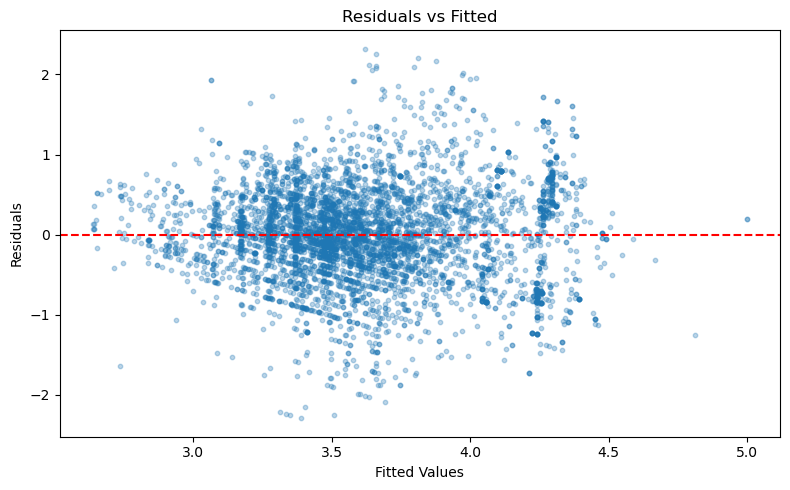

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(m5.fittedvalues, m5.resid, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")
plt.tight_layout()
plt.savefig(
    "residuals_vs_fitted.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)
plt.show()


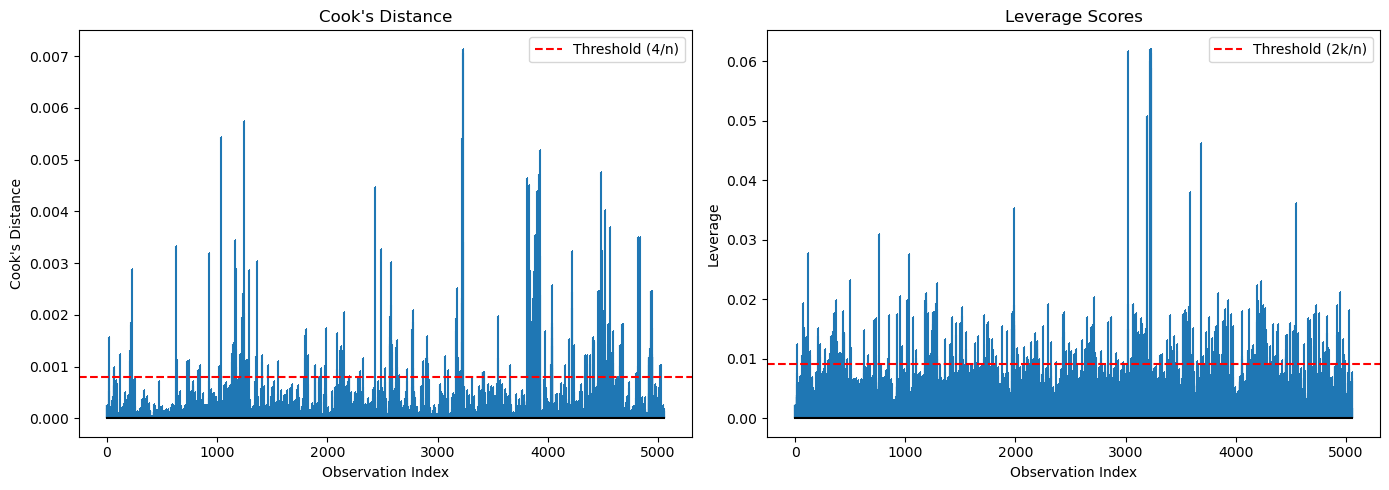

In [44]:


influence = OLSInfluence(m5)
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cook's Distance
axes[0].stem(range(len(cooks_d)), cooks_d, markerfmt=",", linefmt="C0-", basefmt="k-")
axes[0].axhline(4/len(cooks_d), color='red', linestyle='--', label=f"Threshold (4/n)")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Cook's Distance")
axes[0].set_title("Cook's Distance")
axes[0].legend()

# Leverage
axes[1].stem(range(len(leverage)), leverage, markerfmt=",", linefmt="C0-", basefmt="k-")
axes[1].axhline(2 * m5.df_model / len(leverage), color='red', linestyle='--', label="Threshold (2k/n)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Leverage")
axes[1].set_title("Leverage Scores")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    "influence_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)
plt.show()


In [45]:
# Check for large residuals
residuals = m5.resid
std_residuals = m5.resid / m5.resid.std()

print(f"Residuals beyond ±2 std: {(abs(std_residuals) > 2).sum()} ({(abs(std_residuals) > 2).mean():.1%})")
print(f"Residuals beyond ±3 std: {(abs(std_residuals) > 3).sum()} ({(abs(std_residuals) > 3).mean():.1%})")
print(f"\nMax residual: {residuals.max():.3f}")
print(f"Min residual: {residuals.min():.3f}")

Residuals beyond ±2 std: 265 (5.2%)
Residuals beyond ±3 std: 48 (0.9%)

Max residual: 2.320
Min residual: -2.291


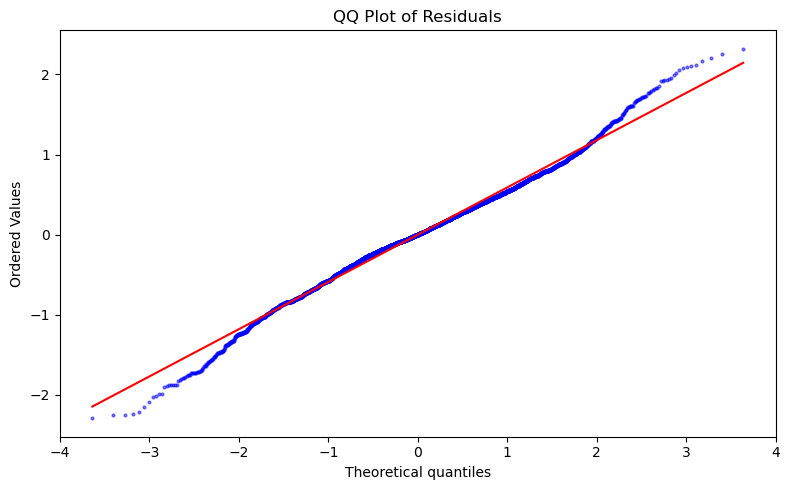

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
stats.probplot(m5.resid, dist="norm", plot=ax)
ax.get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
ax.get_lines()[1].set(color='red')
ax.set_title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

In [49]:
print(m1.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     260.4
Date:                Wed, 13 May 2026   Prob (F-statistic):          2.59e-248
Time:                        22:01:32   Log-Likelihood:                -4764.7
No. Observations:                5056   AIC:                             9541.
Df Residuals:                    5050   BIC:                             9581.
Df Model:                           5                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [50]:
print(m2.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     139.7
Date:                Wed, 13 May 2026   Prob (F-statistic):          7.04e-259
Time:                        22:01:35   Log-Likelihood:                -4687.9
No. Observations:                5056   AIC:                             9398.
Df Residuals:                    5045   BIC:                             9470.
Df Model:                          10                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [51]:
print(m3.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     118.3
Date:                Wed, 13 May 2026   Prob (F-statistic):          1.16e-260
Time:                        22:01:37   Log-Likelihood:                -4681.7
No. Observations:                5056   AIC:                             9389.
Df Residuals:                    5043   BIC:                             9474.
Df Model:                          12                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [52]:
print(m4.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     88.86
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        22:01:39   Log-Likelihood:                -4547.1
No. Observations:                5056   AIC:                             9138.
Df Residuals:                    5034   BIC:                             9282.
Df Model:                          21                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [53]:
print(m5.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     84.03
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        22:01:41   Log-Likelihood:                -4521.1
No. Observations:                5056   AIC:                             9090.
Df Residuals:                    5032   BIC:                             9247.
Df Model:                          23                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------